In [19]:
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

%matplotlib inline
from io import BytesIO

import kagglehub
from PIL import Image
from sklearn import metrics
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    MaxPooling2D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from tqdm import tqdm

In [20]:
BATCH_SIZE = 128
IMAGE_SIZE = (224, 224)

In [21]:
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print("Path to dataset files:", path)

base_path = os.path.join(path, "real_vs_fake", "real-vs-fake")

Path to dataset files: /home/tiberiu/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2


In [22]:
def ela(image_path, scale=(224, 224), quality=90):
    """
    Performs Error Level Analysis (ELA) on an image and returns a 3-channel RGB result.

    Args:
        image_path (str): Path to the image file.
        scale (tuple): Resize dimensions (width, height).
        quality (int): JPEG quality for recompression.

    Returns:
        np.ndarray: 3-channel ELA image in RGB format (uint8).
    """
    # Load and resize image
    image = Image.open(image_path).convert("RGB")
    image = image.resize(scale)

    # Save recompressed image to memory (not disk)
    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)

    compressed = Image.open(buffer)

    # Compute ELA
    diff = np.abs(
        np.array(image, dtype=np.int16) - np.array(compressed, dtype=np.int16)
    )
    diff = np.clip(diff * 10, 0, 255).astype(np.uint8)

    return diff

In [23]:
ela_dir = os.path.join(base_path, "ela_images")
os.makedirs(ela_dir, exist_ok=True)

for stage in ["train", "valid", "test"]:
    stage_dir = os.path.join(base_path, stage)
    os.makedirs(stage_dir, exist_ok=True)

    for category in ["real", "fake"]:
        input_dir = os.path.join(stage_dir, category)
        output_dir = os.path.join(ela_dir, stage, category)

        if os.path.exists(output_dir) and os.listdir(output_dir):
            print(f"Skipping {stage}/{category} (already processed)")
            continue

        os.makedirs(output_dir, exist_ok=True)

        for filename in tqdm(
                os.listdir(input_dir), desc=f"Processing {stage}/{category}"
        ):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                input_path = os.path.join(input_dir, filename)
                output_path = os.path.join(output_dir, filename)
                ela_image = ela(input_path, IMAGE_SIZE)
                Image.fromarray(ela_image).save(output_path)

ela_dir = os.path.join(base_path, "ela_images")
train_dir = os.path.join(ela_dir, "train")
val_dir = os.path.join(ela_dir, "valid")
test_dir = os.path.join(ela_dir, "test")

Skipping train/real (already processed)
Skipping train/fake (already processed)
Skipping valid/real (already processed)
Skipping valid/fake (already processed)
Skipping test/real (already processed)
Skipping test/fake (already processed)


In [24]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [25]:
def build_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)):
    model = Sequential(
        [
            Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            Conv2D(128, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(128, activation="relu"),
            Dropout(0.5),
            Dense(2, activation="softmax"),
        ]
    )
    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


model = build_model()
model.summary()

/home/tiberiu/Documents/Disertatie/140-ela/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
plot_model(
    model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 172ms/step - accuracy: 0.7240 - loss: 0.5404 - precision: 0.7240 - recall: 0.7240 - val_accuracy: 0.8133 - val_loss: 0.4175 - val_precision: 0.8133 - val_recall: 0.8133
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 249s 159ms/step - accuracy: 0.8205 - loss: 0.4054 - precision: 0.8205 - recall: 0.8205 - val_accuracy: 0.8492 - val_loss: 0.3549 - val_precision: 0.8492 - val_recall: 0.8492
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 251s 160ms/step - accuracy: 0.8504 - loss: 0.3484 - precision: 0.8504 - recall: 0.8504 - val_accuracy: 0.8636 - val_loss: 0.3127 - val_precision: 0.8636 - val_recall: 0.8636


In [28]:
if not os.path.exists("models"):
    os.makedirs("models", exist_ok=True)

model.save("models/ela_face_classifier.keras")

# Plotting Accuracy and Loss Graph:

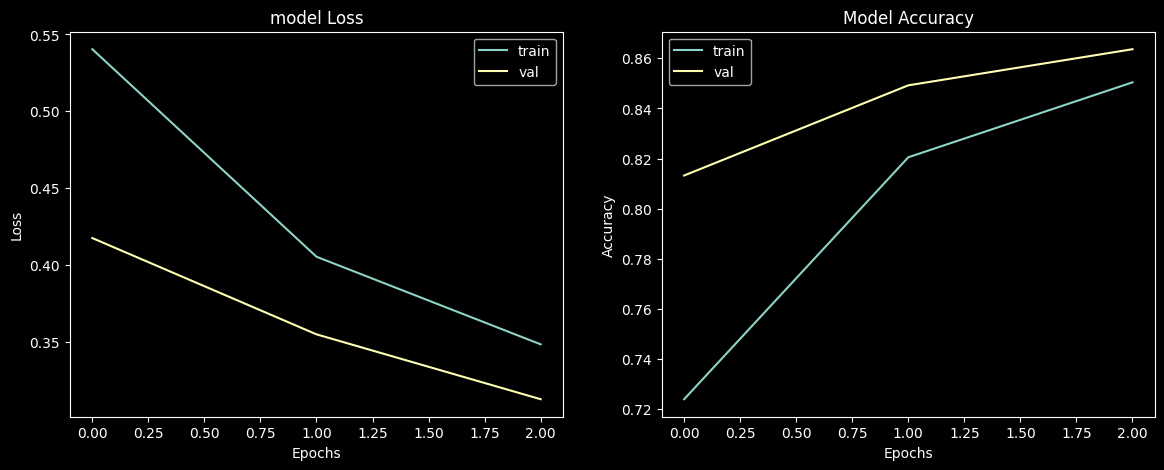

In [40]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()

# Confusion Matrix:

In [30]:
y_pred = model.predict(test_generator)

y_test = test_generator.classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step


In [31]:
y_pred_labels = np.argmax(y_pred, axis=1)

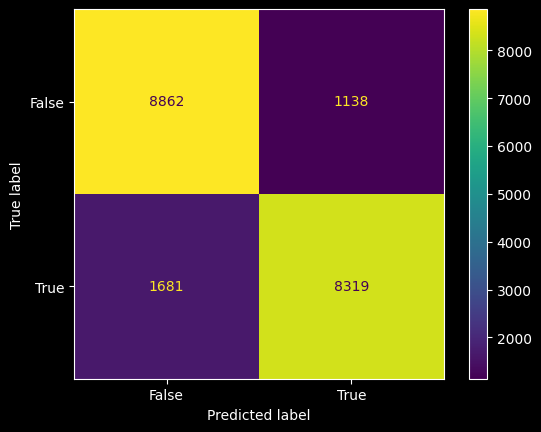

In [39]:
Fake = False
Real = True
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=metrics.confusion_matrix(y_test, y_pred_labels),
    display_labels=[Fake, Real],
)

cm_display.plot()
plt.show()

# ROC AUC Score, Precision Score and Test Accuracy:

In [33]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_labels))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_labels))
print(metrics.classification_report(y_test, y_pred_labels))

ROC AUC Score: 0.8590500000000001
AP Score: 0.8158440255895105
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     10000
           1       0.88      0.83      0.86     10000

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



In [34]:
_, accu, _, _ = model.evaluate(test_generator)
print("Final Test Acccuracy = {:.3f}".format(accu * 100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8590 - loss: 0.3240 - precision: 0.8590 - recall: 0.8590
Final Test Acccuracy = 85.905


# Testing for a random image:

In [35]:
img_path = os.path.join(ela_dir, "test", "real", "00001.jpg")
ela_image = ela(os.path.join(ela_dir, "test", "real", "00001.jpg"), IMAGE_SIZE)
p1 = ela_image.astype(np.float32) / 255.0
p1 = np.expand_dims(p1, axis=0)
p1.shape

(1, 224, 224, 3)

In [36]:
op = np.argmax(model.predict(p1), axis=-1)
print(op)
if op == [0]:
    print("Fake Face")
else:
    print("Real Face")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
[1]
Real Face
